# Pre analysis

## Loading Data

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [218]:
df = pd.read_csv('../data/listings.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn Types:\n{df.dtypes}")

Shape: (48895, 16)

Column Types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


Last review is the date of last review, and now it's stored in object data type
We need to change it into Datetime type

In [219]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Inspecting

In [220]:
# missing values

missing = df.isnull().sum()
print("missing values:\n", missing)


missing values:
 id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [221]:
print("\n\nmissing values prc:\n", missing/len(df) * 100)



missing values prc:
 id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64


In [222]:
# duplicates

duplicates = df.duplicated().sum()
print("duplicates =", duplicates)

duplicates = 0


In [223]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


## Data Cleaning

Small amounts of name and host names are empty. Since those are not significantly large, we can simply drop those rows.

We have about 20 percent of both "last_review" and "reviews_per_month" empty. It means these are new listings, with no review yet. We will need to either fill them, or drop the columns.

In [224]:
# dropping rows

df = df.dropna(subset=["name", "host_name"])

In [225]:
# Filling empty columns

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df["last_review"] = df["last_review"].fillna("No Review.")

In [226]:
# checking if everything worked

missing = df.isnull().sum()
print("missing values:\n", missing)
duplicates = df.duplicated().sum()
print("\n\nduplicates =", duplicates)

missing values:
 id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


duplicates = 0


Now we have to change the "last review" column into the datetime, and have no problems with not a datetime rows

In [227]:
df["last_review"] = pd.to_datetime(df["last_review"], errors = 'coerce')

print(df["last_review"].dtype)
print(df['last_review'].isna().sum())

datetime64[ns]
10037


## Now we have to deal with outliers.

In [228]:
df = df[(df.price>=10) & (df.price<=1000)]
df.shape

(48608, 16)

In [229]:
print(df['minimum_nights'].describe())
print(df[df['minimum_nights'] > 365].shape)

count    48608.000000
mean         6.955810
std         19.767603
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64
(13, 16)


In [230]:
df = df[df['minimum_nights'] <= 365]
df.shape

(48595, 16)

Now we have to drop columns, which are not helpful to us. Specifically id and host id

In [231]:
df.drop("id", inplace=True, axis=1)
df.drop("host_id", inplace=True, axis=1)
df.columns

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [232]:
print(df.shape)
print(df.isnull().sum())

(48595, 14)
name                                 0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9897
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
dtype: int64


## Adding new features

In [233]:
#days since last review:

df["days_since_last_review"] = (pd.Timestamp('today') - df.last_review).dt.days
df['days_since_last_review'].describe()

count    38698.000000
mean      2752.181353
std        413.263855
min       2476.000000
25%       2491.000000
50%       2526.000000
75%       2838.000000
max       5500.000000
Name: days_since_last_review, dtype: float64

In [234]:
# host_listing_tier:

conditions = [
    df.calculated_host_listings_count == 1,
    df.calculated_host_listings_count < 6,
    df.calculated_host_listings_count >= 6 
]
choices = ['new', 'established', 'power']

df = df.reset_index(drop=True)

df['host_listing_tier'] = np.select(conditions, choices, default='unknown')

print(df['host_listing_tier'].value_counts())

host_listing_tier
new            32093
established    11748
power           4754
Name: count, dtype: int64


In [235]:
# review_activity:

df['review_activity'] = (df['reviews_per_month'] > 0).astype(int)

df['review_activity'].value_counts()

review_activity
1    38698
0     9897
Name: count, dtype: int64

In [236]:
#availability_rate:

df["availability_rate"] = (df['availability_365'] / 365).round(2)

df['availability_rate'].describe()

count    48595.000000
mean         0.307965
std          0.360007
min          0.000000
25%          0.000000
50%          0.120000
75%          0.620000
max          1.000000
Name: availability_rate, dtype: float64

In [237]:
df['price_per_room_type'] = df.groupby('room_type')['price'].transform('mean').round(2)
print(df.groupby('room_type')['price_per_room_type'].first())

room_type
Entire home/apt    194.63
Private room        84.80
Shared room         67.64
Name: price_per_room_type, dtype: float64


# Analysis

In [238]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

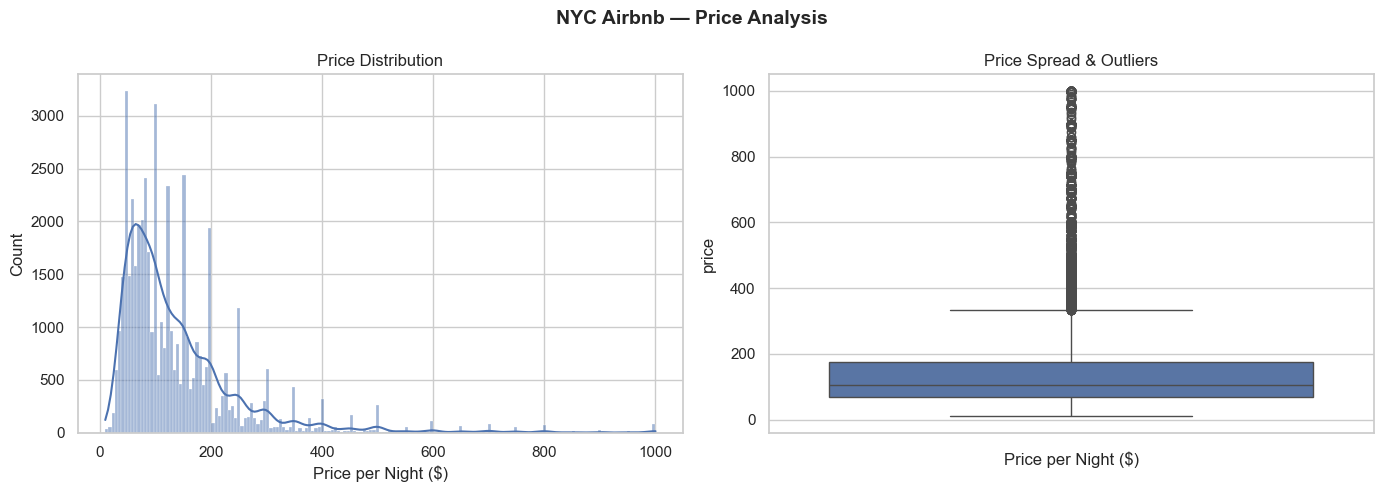

In [239]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df.price, ax=axes[0], kde=True)
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price per Night ($)')

sns.boxplot(df.price, ax=axes[1])
axes[1].set_title('Price Spread & Outliers')
axes[1].set_xlabel('Price per Night ($)')

fig.suptitle('NYC Airbnb — Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

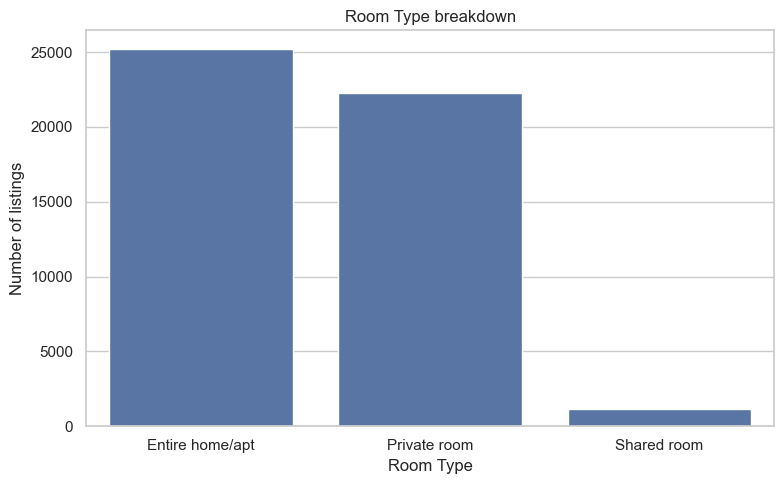

In [240]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data = df, x = df.room_type, ax = ax, order=df['room_type'].value_counts().index)

ax.set_title('Room Type breakdown')
ax.set_xlabel("Room Type")
ax.set_ylabel("Number of listings")

plt.tight_layout()
plt.savefig('../visuals/Room type.png', dpi=150, bbox_inches='tight')
plt.show()

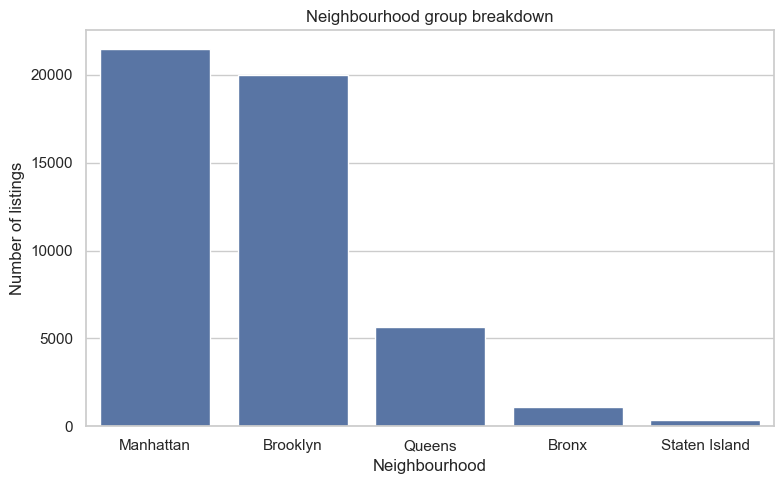

In [241]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data = df, x = "neighbourhood_group", ax = ax, order=df['neighbourhood_group'].value_counts().index)

ax.set_title('Neighbourhood group breakdown')
ax.set_xlabel("Neighbourhood")
ax.set_ylabel("Number of listings")

plt.tight_layout()
plt.savefig('../visuals/Neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()

The neighbourhood breakdown tells a strong story:

Manhattan and Brooklyn dominate — together they account for ~85% of all listings

Queens is a distant third

Bronx and Staten Island are nearly invisible at this scale

*Business insight*: Supply is heavily concentrated in two boroughs. A new host in Queens or the Bronx faces far less competition — worth flagging.

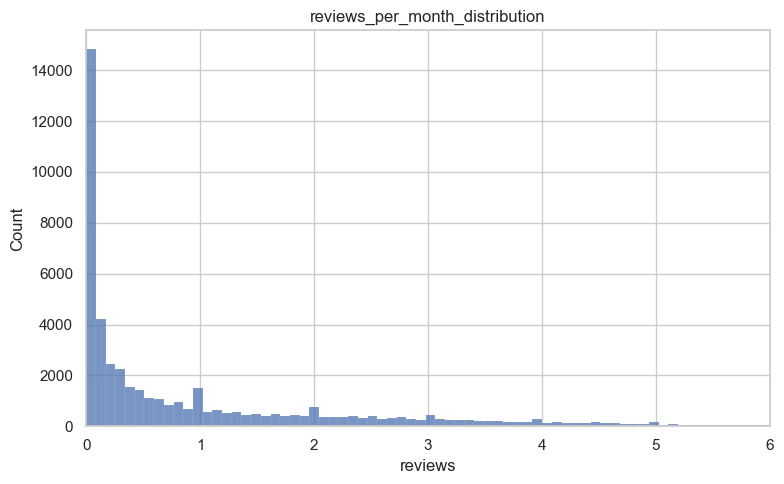

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(data = df, x = "reviews_per_month", ax = ax)
ax.set_xlim(0, 6)

ax.set_title('Reviews per month distribution')
ax.set_xlabel("reviews")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig('../visuals/reviews_per_month_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Business insight from this chart: The vast majority of active listings receive fewer than 2 reviews per month. Anything above 5 reviews/month is a genuinely high-performing listing — useful context for Question 3 when you compare host tiers.